# 🔧 LoRA Training (Stable Diffusion XL (SDXL))

## Step 1 : Dependency Installation

In [2]:
!conda install -y -c conda-forge sentencepiece pyarrow datasets

%pip install --force-reinstall \
  bitsandbytes \
  einops \
  pytorch-lightning \
  prodigyopt \
  lion-pytorch \
  opencv-python \
  ftfy \
  tensorboard \
  altair \
  easygui \
  toml \
  voluptuous \
  imagesize \
  "huggingface_hub==0.36.0" \
  "transformers==4.57.5" \
  peft

!rm -rf /home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/huggingface_hub-1.3.1.dist-info

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.

  Using cached bitsandbytes-0.49.1-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
  Using cached einops-0.8.1-py3-none-any.whl.metadata (13 kB)
  Using cached pytorch_lightning-2.6.0-py3-none-any.whl.metadata (21 kB)
  Using cached prodigyopt-1.1.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached lion_pytorch-0.2.3-py3-none-any.whl.metadata (616 bytes)
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached easygui-0.98.3-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Usi

In [8]:
# Dependency Check Here
# opencv-python Missing is OK Only for GUI

import importlib

libs_to_check = [
    # Hugging Face core
    "torch", "torchvision", "torchaudio",
    "transformers", "diffusers", "accelerate",

    # Memory/optimization
    #"xformers", 
    "bitsandbytes", "safetensors", "einops",

    # Training frameworks
    "pytorch_lightning", "prodigyopt", "lion_pytorch",

    # Data & preprocessing
    #"opencv-python", 
    "cv2", "PIL", "ftfy", "sentencepiece", "datasets",

    # Utils & viz
    "tensorboard", "huggingface_hub", "altair", "easygui",
    "toml", "voluptuous", "imagesize", "rich"
]

# special cases where version attribute differs
special_version_attrs = {
    "cv2": "version",
    "PIL": "PILLOW_VERSION",  # old
}

for lib in libs_to_check:
    try:
        module_name = lib.replace("-", "_")
        module = importlib.import_module(module_name)

        # try __version__, or special attributes, or unknown
        version = getattr(module, "__version__", None)
        if version is None:
            # handle cv2, PIL, etc.
            if lib in special_version_attrs:
                version = getattr(module, special_version_attrs[lib], None)
            elif lib == "PIL":
                try:
                    import PIL
                    version = getattr(PIL, "__version__", None)
                except Exception:
                    version = None

        print(f"✅ {lib} - {version if version else 'unknown'}")

    except Exception as e:
        print(f"❌ {lib} - MISSING ({e.__class__.__name__})")

✅ torch - 2.6.0+cu124
✅ torchvision - 0.21.0+cu124
✅ torchaudio - 2.6.0+cu124
✅ transformers - 4.57.5
✅ diffusers - 0.36.0
✅ accelerate - 1.12.0
✅ bitsandbytes - 0.49.1
✅ safetensors - 0.7.0
✅ einops - 0.8.1
✅ pytorch_lightning - 2.6.0
✅ prodigyopt - unknown
✅ lion_pytorch - unknown
✅ cv2 - 4.12.0
✅ PIL - 12.1.0
✅ ftfy - 6.3.1
✅ sentencepiece - 0.2.1
✅ datasets - 4.4.2
✅ tensorboard - 2.20.0
✅ huggingface_hub - 0.36.0
✅ altair - 6.0.0
✅ easygui - unknown
✅ toml - 0.10.2
✅ voluptuous - 0.16.0
✅ imagesize - 1.4.1
✅ rich - unknown


## STEP 2 — Project Config

In this step, we set up the project details and training parameters:  

- **Project Name** — used to create folders for datasets, outputs, and logs.  
- **Trigger Word** — a unique token (e.g., `akashawriter`) that activates your LoRA.  
- **Paths** — dataset, images, outputs, and logs are auto-created in Google Drive.

In [2]:
# ==== USER CONFIG ====
PROJECT_NAME = "SDXLORA"
TRIGGER      = "SDXLORA"

# Paths
DATASET_DIR  = f"./content/{PROJECT_NAME}/"
IMAGES_DIR   = f"./content/{PROJECT_NAME}/5_{TRIGGER}/"
OUTPUT_DIR   = f"./content/lora/LoRA_Output/{PROJECT_NAME}"
LOG_DIR      = f"./content/lora/LoRA_Logs/{PROJECT_NAME}"

# Create folders if not exist
import os
for p in [DATASET_DIR, OUTPUT_DIR, LOG_DIR, IMAGES_DIR]:
    os.makedirs(p, exist_ok=True)

print("✅ Folders ready:")
print("📂 Dataset Dir :", DATASET_DIR)
print("📂 Images Dir  :", IMAGES_DIR)
print("📂 Output Dir  :", OUTPUT_DIR)
print("📂 Log Dir     :", LOG_DIR)
print("\n⚡ Place your training images inside:", IMAGES_DIR)


✅ Folders ready:
📂 Dataset Dir : ./content/SDXLORA/
📂 Images Dir  : ./content/SDXLORA/5_SDXLORA/
📂 Output Dir  : ./content/lora/LoRA_Output/SDXLORA
📂 Log Dir     : ./content/lora/LoRA_Logs/SDXLORA

⚡ Place your training images inside: ./content/SDXLORA/5_SDXLORA/


## STEP 3 — Train LoRA (kohya-ss `sdxl_train_network.py`)
**Tips:**
- Start with the defaults. If results look samey/overfit, reduce `MAX_STEPS` or improve dataset.
- If underfit (not learning your subject), **increase** `MAX_STEPS` to 6–8k or improve captions.
- Keep `NETWORK_DIM` at 16/32 for small, flexible LoRAs.

- **Resolution** — choose `512` (faster, lighter) or `768` (more detail, higher VRAM).  
- **Batch Size** — set to `1` (use `2` if GPU has enough VRAM).  
- **Max Steps** — training iterations (start with 3k–5k, adjust based on results).  
- **Network Dim / Alpha** — controls LoRA size & capacity (16–32 is common).  
- **Learning Rates** — fine-tuned for text encoder and U-Net.  

👉 If you’re unsure, keep the defaults — they work well for most cases.  

In [13]:
import os

# ----------------------
# CONFIG
# ----------------------
PRETRAINED_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"
# MODEL_DIR

# Hyperparameters tuned for A100/L4
RESOLUTION        = 512          # 768 or lesser is safe for Weaker GPU
BATCH_SIZE        = 1             # Chnage it according to power
GRAD_ACC_STEPS    = 2             # Chnage it according to power
MAX_STEPS         = 150
NETWORK_DIM       = 32
NETWORK_ALPHA     = 16
LEARNING_RATE     = 1.0            # Prodigy expects ~1.0, not 1e-4

# ----------------------
# TRAINING COMMAND
# ----------------------

train_cmd = f'''
accelerate launch --mixed_precision=fp16 ./content/sdxl_train_network.py \
  --pretrained_model_name_or_path="{PRETRAINED_MODEL}" \
  --train_data_dir="{DATASET_DIR}" \
  --output_dir="{OUTPUT_DIR}" \
  --logging_dir="{LOG_DIR}" \
  --resolution={RESOLUTION} \
  --network_module=networks.lora \
  --network_dim={NETWORK_DIM} \
  --network_alpha={NETWORK_ALPHA} \
  --learning_rate={LEARNING_RATE} \
  --train_batch_size={BATCH_SIZE} \
  --gradient_accumulation_steps={GRAD_ACC_STEPS} \
  --max_train_steps={MAX_STEPS} \
  --save_every_n_steps=500 \
  --save_last_n_steps=3 \
  --save_last_n_epochs=3 \
  --save_state \
  --save_precision=fp16 \
  --optimizer_type=Prodigy \
  --mem_eff_attn \
  --shuffle_caption \
  --caption_extension=.txt \
  --max_data_loader_n_workers=2 \
  --log_prefix="female_writer_v1" \
  --enable_bucket \
  --bucket_reso_steps=64 \
  --random_crop \
  --log_with tensorboard \
  2>&1 | tee ./content/train.log
'''

# ----------------------
# RUN TRAINING
# ----------------------
print("🚀 Starting LoRA training...\n")
exit_code = os.system(train_cmd)
print("\n✅ Training finished with exit code:", exit_code)

🚀 Starting LoRA training...

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that instal

## STEP 4 — Test the LoRA
This loads SD1.5 and your LoRA, only do once.

In [3]:
import os, glob
import gc
from diffusers import StableDiffusionXLPipeline
import torch

# find latest safetensors in output
lora_files = sorted([p for p in glob.glob(os.path.join(OUTPUT_DIR, "*.safetensors"))], key=os.path.getmtime)
assert lora_files, "No LoRA files found in OUTPUT_DIR. Check training output."
LORA_PATH = lora_files[-1]
print("Using LoRA:", LORA_PATH)

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    dtype=torch.float16,          
    use_safetensors=True,         
).to("cuda")

# Load LoRA
pipe.load_lora_weights(os.path.dirname(LORA_PATH), weight_name=os.path.basename(LORA_PATH))

print("Model is loaded!")

Using LoRA: ./content/lora/LoRA_Output/SDXLORA/last.safetensors


Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model is loaded!


## Use the cell below to generate images.

Image generation started!


  0%|          | 0/30 [00:00<?, ?it/s]

Saved sample_lora_output.png


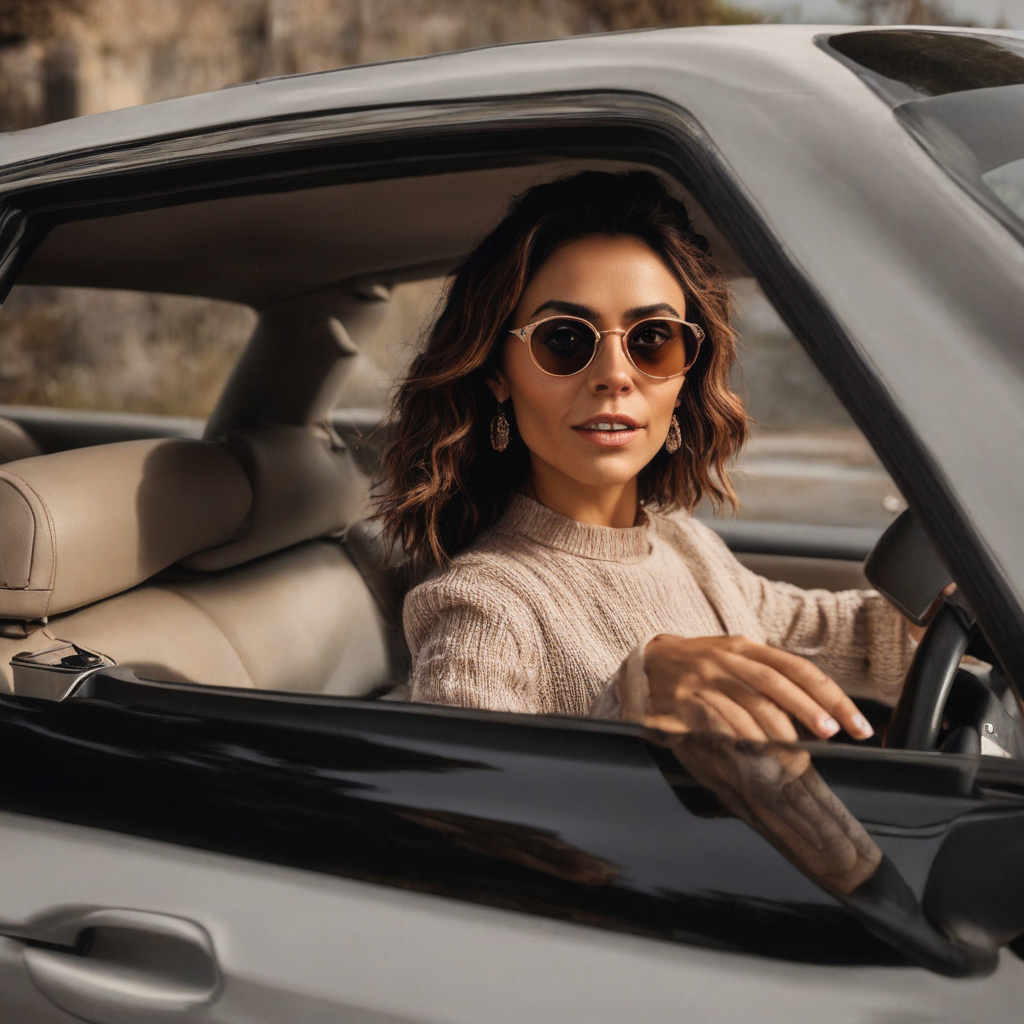

In [6]:
RESOLUTION = 1024

prompt = f"Photo of {TRIGGER} driving a car"
neg = "cartoon, anime, illustration, blurry, low quality, bad proportions, deformation watermark, logo, text"

print("Image generation started!")
image = pipe(prompt, negative_prompt=neg, num_inference_steps=30, guidance_scale=7.5, height=RESOLUTION, width=RESOLUTION).images[0]

image.save("sample_lora_output.png")
print("Saved sample_lora_output.png")
display(image)